# Full Agentic RAG Pipeline [Step 4 - Retrieve, Rephrase, or Answer]

> **MLCourse - Agentic AI - Agentic RAG**

This notebook combines all previous concepts into a single LangGraph
pipeline. The agent decides at each step: retrieve new documents, rephrase
the query for better results, or answer directly. The graph includes
retry logic, query refinement, and a final answer node.

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

False

In [2]:
api_key = os.environ.get("OPENAI_API_KEY", "")
if api_key:
    print("[GREEN] API key found")
else:
    print("[GREEN] No API key needed -- using local ChatOllama")

[GREEN] No API key needed -- using local ChatOllama


In [3]:
# ## 1. Load and Chunk the Document

from langchain_text_splitters import CharacterTextSplitter

text_path = r"D:\projects\python\MLCourse\03_agentic_ai\data\alice.txt"
with open(text_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_text(raw_text)
print(f"Loaded alice.txt: {len(raw_text)} chars -> {len(chunks)} chunks")

Loaded alice.txt: 144696 chars -> 191 chunks


In [4]:
# ## 2. Build the Vector Store

from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma

embeddings = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = Chroma.from_texts(chunks, embeddings, collection_name="alice_agentic")
print(f"Vector store built with {vectorstore._collection.count()} vectors")

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Retriever ready.")

Vector store built with 191 vectors
Retriever ready.


In [5]:
# ## 3. Initialize the LLM

from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("LLM initialized:", llm.model)

LLM initialized: llama3.1:8b


In [6]:
# ## 4. Define the Agent State
# The state tracks the full lifecycle: original query, current (possibly
# rephrased) query, retrieved context, the agent's decision, retry count,
# and the final answer.

from typing import TypedDict, Literal

class AgenticRAGState(TypedDict):
    original_query: str       # The user's initial query
    current_query: str        # The query being processed (may be rephrased)
    retrieved_context: str    # Concatenated document content
    decision: str             # "retrieve", "rephrase", or "answer_directly"
    answer: str               # Final or intermediate answer
    retry_count: int          # How many rephrases have been attempted
    max_retries: int          # Cap on rephrase attempts

print("State defined with query tracking and retry logic.")

State defined with query tracking and retry logic.


In [7]:
# ## 5. Build the Decision Node (Router)
# The agent examines the current query and decides the next action:
# - "retrieve": fetch documents for the current query
# - "rephrase": the query is too vague or retrieval failed, try rephrasing
# - "answer_directly": general knowledge, no retrieval needed

from langchain_core.prompts import ChatPromptTemplate

decision_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an agentic RAG router. Given a query and its context, decide "
     "the next action.\n\n"
     "RULES:\n"
     "- Return 'answer_directly' if the query is general knowledge, a greeting, "
     "or an opinion request that does not need document retrieval.\n"
     "- Return 'retrieve' if the query is about specific content that requires "
     "document lookup and no context has been provided yet.\n"
     "- Return 'rephrase' if previous retrieval was attempted but the context "
     "does not contain useful information, or if the query is too vague.\n\n"
     "Reply with ONLY one word: 'retrieve', 'rephrase', or 'answer_directly'."),
    ("user", "Query: {query}\nContext provided: {has_context}\nRetry count: {retry_count}")
])

def decide_action(state: AgenticRAGState) -> dict:
    """Node: Decide whether to retrieve, rephrase, or answer directly."""
    has_context = "yes" if state.get("retrieved_context") else "no"
    response = (decision_prompt | llm).invoke({
        "query": state["current_query"],
        "has_context": has_context,
        "retry_count": state.get("retry_count", 0)
    })
    decision = response.content.strip().lower()
    if decision not in ("retrieve", "rephrase", "answer_directly"):
        decision = "retrieve"
    print(f"  [DECIDE] decision={decision}, query='{state['current_query'][:60]}...'")
    return {"decision": decision}

In [8]:
# ## 6. Build the Retrieval Node

def retrieve_documents(state: AgenticRAGState) -> dict:
    """Node: Retrieve documents and check if they are useful."""
    query = state["current_query"]
    docs = retriever.invoke(query)
    context = "\n\n---\n\n".join([d.page_content for d in docs])

    # Quick relevance check: does the context contain useful content?
    relevance_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Rate whether the provided context is relevant to the query. "
         "Reply with ONLY 'relevant' or 'not_relevant'."),
        ("user", "Query: {query}\nContext (first 500 chars): {context}")
    ])
    check = (relevance_prompt | llm).invoke({
        "query": query,
        "context": context[:500]
    })
    relevance = check.content.strip().lower()

    if "not_relevant" in relevance:
        print(f"  [RETRIEVE] Got {len(docs)} docs but they are NOT relevant")
        return {"retrieved_context": "", "retry_count": state.get("retry_count", 0) + 1}

    print(f"  [RETRIEVE] Got {len(docs)} relevant docs ({len(context)} chars)")
    return {"retrieved_context": context}

In [9]:
# ## 7. Build the Query Rephraser Node
# When retrieval fails or the query is too vague, the agent rephrases it
# to be more specific. This is the "adaptive" part of agentic RAG.

rephrase_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a query rephraser. The original query did not retrieve useful "
     "documents. Rephrase it to be more specific and searchable.\n\n"
     "RULES:\n"
     "- Make the query more specific and concrete\n"
     "- Preserve the original intent\n"
     "- Add relevant keywords that a document might contain\n"
     "- Do NOT add information that was not in the original query"),
    ("user", "Original query: {original_query}\nCurrent attempt: {current_query}")
])

def rephrase_query(state: AgenticRAGState) -> dict:
    """Node: Rephrase the query to improve retrieval."""
    response = (rephrase_prompt | llm).invoke({
        "original_query": state["original_query"],
        "current_query": state["current_query"]
    })
    new_query = response.content.strip()
    print(f"  [REPHRASE] '{state['current_query'][:50]}...' -> '{new_query[:50]}...'")
    return {"current_query": new_query}

In [10]:
# ## 8. Build the Answer Nodes

answer_with_context_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer the user's question using ONLY the provided context. "
     "If the context does not contain enough information, say so clearly. "
     "Be concise and accurate."),
    ("user", "Context:\n{context}\n\nQuestion: {query}")
])

answer_direct_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer the user's question from your general knowledge. "
     "Be concise and helpful."),
    ("user", "{query}")
])

def answer_with_context(state: AgenticRAGState) -> dict:
    """Node: Answer using retrieved context."""
    response = (answer_with_context_prompt | llm).invoke({
        "context": state["retrieved_context"],
        "query": state["current_query"]
    })
    print(f"  [ANSWER-WITH-CONTEXT] {response.content[:80]}...")
    return {"answer": response.content}

def answer_directly(state: AgenticRAGState) -> dict:
    """Node: Answer without retrieval (general knowledge)."""
    response = (answer_direct_prompt | llm).invoke({"query": state["current_query"]})
    print(f"  [ANSWER-DIRECT] {response.content[:80]}...")
    return {"answer": response.content}

In [11]:
# ## 9. Build the Retry Guard Node
# Checks if we have exceeded the retry limit. If so, force a direct answer.

def check_retry_limit(state: AgenticRAGState) -> dict:
    """Node: Check retry count and force answer if limit exceeded."""
    retry = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 2)
    if retry >= max_retries:
        print(f"  [RETRY-GUARD] Max retries ({max_retries}) reached. Forcing answer.")
    return {}

In [12]:
# ## 10. Define All Routing Logic

def route_after_decide(state: AgenticRAGState) -> Literal["retrieve_documents", "rephrase_query", "answer_directly"]:
    """Route based on the agent's decision."""
    d = state["decision"]
    if d == "retrieve":
        return "retrieve_documents"
    elif d == "rephrase":
        return "rephrase_query"
    else:
        return "answer_directly"

def route_after_retrieve(state: AgenticRAGState) -> Literal["answer_with_context", "rephrase_query"]:
    """After retrieval, check if context is useful."""
    if state.get("retrieved_context"):
        return "answer_with_context"
    return "rephrase_query"

def route_after_rephrase(state: AgenticRAGState) -> Literal["decide", "__end__"]:
    """After rephrasing, go back to decision or give up."""
    retry = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 2)
    if retry >= max_retries:
        return "__end__"
    return "decide"

In [13]:
# ## 11. Build the LangGraph

from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgenticRAGState)

# Nodes
graph_builder.add_node("decide", decide_action)
graph_builder.add_node("retrieve_documents", retrieve_documents)
graph_builder.add_node("rephrase_query", rephrase_query)
graph_builder.add_node("answer_with_context", answer_with_context)
graph_builder.add_node("answer_directly", answer_directly)
graph_builder.add_node("check_retry_limit", check_retry_limit)

# Entry
graph_builder.add_edge(START, "decide")

# From decide -> retrieve / rephrase / answer_directly
graph_builder.add_conditional_edges(
    "decide",
    route_after_decide,
    {
        "retrieve_documents": "retrieve_documents",
        "rephrase_query": "rephrase_query",
        "answer_directly": "answer_directly",
    }
)

# From retrieve -> answer or rephrase
graph_builder.add_conditional_edges(
    "retrieve_documents",
    route_after_retrieve,
    {
        "answer_with_context": "answer_with_context",
        "rephrase_query": "rephrase_query",
    }
)

# From rephrase -> back to decide (loop) or end
graph_builder.add_conditional_edges(
    "rephrase_query",
    route_after_rephrase,
    {
        "decide": "decide",
        "__end__": END,
    }
)

# Terminal edges
graph_builder.add_edge("answer_with_context", END)
graph_builder.add_edge("answer_directly", END)

graph = graph_builder.compile()
print("Full agentic RAG graph compiled.")

Full agentic RAG graph compiled.


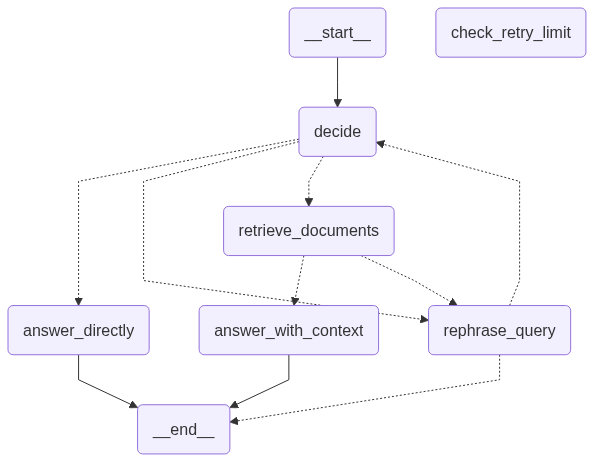

In [14]:
# ## 12. Visualize the Graph

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> decide")
    print("  decide -> retrieve_documents -> [has context?] -> answer_with_context -> END")
    print("  decide -> rephrase_query -> [retry < max?] -> decide (loop)")
    print("  decide -> answer_directly -> END")
    print("  retrieve_documents -> [no context] -> rephrase_query -> decide")
    print("  rephrase_query -> [retry >= max] -> END (fallback)")

In [15]:
# ## 13. Test: Direct Answer (No Retrieval)

print("=" * 60)
print("TEST 1: General knowledge (should answer directly)")
print("=" * 60)
result = graph.invoke({
    "original_query": "What is 2 + 2?",
    "current_query": "What is 2 + 2?",
    "retrieved_context": "",
    "decision": "",
    "answer": "",
    "retry_count": 0,
    "max_retries": 2,
})
print(f"\nFinal answer: {result['answer']}")
print(f"Retries used: {result['retry_count']}")

TEST 1: General knowledge (should answer directly)


  [DECIDE] decision=answer_directly, query='What is 2 + 2?...'


  [ANSWER-DIRECT] The answer is 4....

Final answer: The answer is 4.
Retries used: 0


In [16]:
# ## 14. Test: Successful Retrieval

print("\n" + "=" * 60)
print("TEST 2: Alice-specific question (should retrieve and answer)")
print("=" * 60)
result = graph.invoke({
    "original_query": "Who does Alice meet at the tea party?",
    "current_query": "Who does Alice meet at the tea party?",
    "retrieved_context": "",
    "decision": "",
    "answer": "",
    "retry_count": 0,
    "max_retries": 2,
})
print(f"\nFinal answer: {result['answer']}")
print(f"Retries used: {result['retry_count']}")


TEST 2: Alice-specific question (should retrieve and answer)


  [DECIDE] decision=retrieve, query='Who does Alice meet at the tea party?...'


  [RETRIEVE] Got 4 relevant docs (3595 chars)


  [ANSWER-WITH-CONTEXT] Alice meets the March Hare and the Hatter at the tea party. The Dormouse is also...

Final answer: Alice meets the March Hare and the Hatter at the tea party. The Dormouse is also present, but he is asleep and not actively participating in the conversation.
Retries used: 0


In [17]:
# ## 15. Test: Vague Query (May Trigger Rephrase)

print("\n" + "=" * 60)
print("TEST 3: Vague query (may rephrase before answering)")
print("=" * 60)
result = graph.invoke({
    "original_query": "Tell me about the animals",
    "current_query": "Tell me about the animals",
    "retrieved_context": "",
    "decision": "",
    "answer": "",
    "retry_count": 0,
    "max_retries": 2,
})
print(f"\nFinal answer: {result['answer']}")
print(f"Retries used: {result['retry_count']}")
print(f"Final query was: {result['current_query']}")


TEST 3: Vague query (may rephrase before answering)


  [DECIDE] decision=retrieve, query='Tell me about the animals...'


  [RETRIEVE] Got 4 relevant docs (3167 chars)


  [ANSWER-WITH-CONTEXT] Here are some details about the animals mentioned in the context:

* A Mouse is ...

Final answer: Here are some details about the animals mentioned in the context:

* A Mouse is a main character who has a long and sad tale to tell. It's fond of swimming and can be offended by Alice.
* A Duck is one of the creatures that fell into the pool with the Mouse.
* A Dodo is another creature that fell into the pool.
* A Lory (a type of parrot) is mentioned as being in the pool.
* An Eaglet (a young eagle) is also in the pool.
* Guinea-pigs are mentioned, but they're not described as being present at the scene. Instead, it's said that their squeaking can be heard from elsewhere.
* A Pig-baby is a character who sneezes on the Duchess's knee.
* A Lizard is mentioned as having a slate-pencil and making noise.

There are also some animals mentioned in passing, such as terriers (which Alice mentions as being fond of) and rats (which the farmer says the terrier kills).
Retries

In [18]:
# ## 16. Test: Complex Multi-Part Question

print("\n" + "=" * 60)
print("TEST 4: Complex question about themes and characters")
print("=" * 60)
result = graph.invoke({
    "original_query": (
        "What are the main characters in Alice in Wonderland "
        "and what do they represent?"
    ),
    "current_query": (
        "What are the main characters in Alice in Wonderland "
        "and what do they represent?"
    ),
    "retrieved_context": "",
    "decision": "",
    "answer": "",
    "retry_count": 0,
    "max_retries": 2,
})
print(f"\nFinal answer: {result['answer']}")
print(f"Retries used: {result['retry_count']}")


TEST 4: Complex question about themes and characters


  [DECIDE] decision=retrieve, query='What are the main characters in Alice in Wonderland and what...'


  [RETRIEVE] Got 4 relevant docs (3273 chars)


  [ANSWER-WITH-CONTEXT] The provided context does not contain enough information about the main characte...

Final answer: The provided context does not contain enough information about the main characters in Alice's Adventures in Wonderland. It only mentions a few minor characters, such as:

* The King (who is also the judge)
* The Queen
* The Cheshire Cat

It does mention Alice, but she is the protagonist and narrator of the story, rather than a character that can be analyzed for symbolic meaning.

To answer your question accurately, I would need more context or information about the characters in the story.
Retries used: 0


In [19]:
# ## 17. Inspect Graph Structure

print("=== Graph Structure ===")
g = graph.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print("Edges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'decide', 'retrieve_documents', 'rephrase_query', 'answer_with_context', 'answer_directly', 'check_retry_limit', '__end__']
Edges:
  __start__ -> decide
  decide -> answer_directly
  decide -> rephrase_query
  decide -> retrieve_documents
  rephrase_query -> __end__
  rephrase_query -> decide
  retrieve_documents -> answer_with_context
  retrieve_documents -> rephrase_query
  answer_directly -> __end__
  answer_with_context -> __end__


In [20]:
# ## Summary
#
# Key takeaways:
# - The full agentic RAG pipeline: decide -> retrieve/rephrase/answer
# - Decision node routes to three paths: retrieve, rephrase, or direct answer
# - Rephrasing loop improves retrieval quality when initial queries fail
# - Retry guard prevents infinite loops (critical for production)
# - Context relevance check ensures retrieved docs are actually useful
# - Two terminal paths: answer with context or answer directly
# - The graph is the agent: nodes are actions, edges are decisions
# - This pattern extends naturally: add more nodes (summarize, verify, etc.)